# **Contributions**

<center>

| Name | Sections | Summary |
|:-----------:|:--:|:------:|
| Andrew Long    | A, B, C, D, E, G     | Found the final agreed upon dataset, wrote code for analysis and models, and contributed to tutorial writing. Also helped plan EDA methodology and machine learning techniques.     |
| Xael Shan    | A, B, C, D, E, G     | Eliminating boundary conditions, planning Hypothesis Tests, Post Hoc Analysis, accounting for dataset imbalance, model optimization with GridSearch, wrote related sections in tutorial    |
| Daria Vucea | A, B, C, F, G | Created plots and graphs, graph and section descriptions for preprocessing and analysis and implemented label encoding |
| Catherine Wong | A, B, C, G | Wrote introduction, planned hypothesis testing, primary analysis, and conclusion. |

</center>

**In earnest, our group worked on every section of this project together (gathered in a group call) from project ideation to writing sections for each part.**

# **Introduction**
Diabetes is one of the most widespread chronic diseases in the world, affecting millions of individuals and placing a significant burden on healthcare systems. Early and accurate detection of diabetes risk is critical for supporting public health as a whole. However, identifying risk is not always straightforward; diabetes is influenced by a combination of physiological, demographic, and lifestyle-related factors.
This project focuses on using machine learning models to classify diabetes stages based on available patient health features. We specifically aim to investigate the following questions: Can measurable indicators such as HbA1c, insulin, low-density lipoprotein (LDL) cholesterol, and glucose levels, as well as less conventional indicators such as waist-to-hip ratio and smoking habits, be used to accurately predict whether an individual has diabetes or is at risk of developing it? Additionally, which of these features contribute most significantly to the prediction, and how do they interact with each other to influence the final prediction? Through analysis of the Diabetes Health Indicators dataset, we seek to better understand the relationships between these health variables and diabetes risk.

Additional information about [Diabetes](https://www.who.int/news-room/fact-sheets/detail/diabetes)

# **Importing**

Importing csv as pandas dataframe.

**Source:** Rakesh Kolipaka, and Ranjith Kumar Digutla. (2025). Diabetes Health Indicators Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/13128284

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

df = pd.read_csv("diabetes_dataset.csv")
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


From looking at the head of the dataframe, we can analyze what columns there are. We can see that each row is made up of age, gender, ethnicity, education level, employment status, smoking status, alcohol consumption per week, physical activity, diet score, cholesterol, triglycerides, glucose fasting, glucose postprandial, insulin level, hba1c, diabetes risk score, diabetes statge, and more. When we analyze this data not every column will be used since since only a few will be significant to predicting what diabetes stage a person might have based on other info. However before we get to that, we need to clean the data.

# **Parsing**
Before anything else, we will first check if there are any misisng values. If there are, we will need to handle them accordingly.

In [ ]:
# [ADDED] isna() checks if a cell is Na and the two sums count the null values for all rows and columns
print(f"There are {int(df.isna().sum().sum())} missing values in the dataframe.")

There are 0 missing values in the dataframe.


As we can see above, there are no missing values. Therefore we do not need to handle them.

On another hand, we do believe that there are boundary conditions for two columns which need to be fixed: Ldl Cholesterol and Insulin Level. Their minimum values, (50 and 2 respectively) have counts that are extremely large compared to their neighboring values. Since these two values are recorded from medical instruments, it can be reasoned that the high counts for these minimum values are due to the instruments' not being able to measure anything below the miniumum detection (50 and 2).



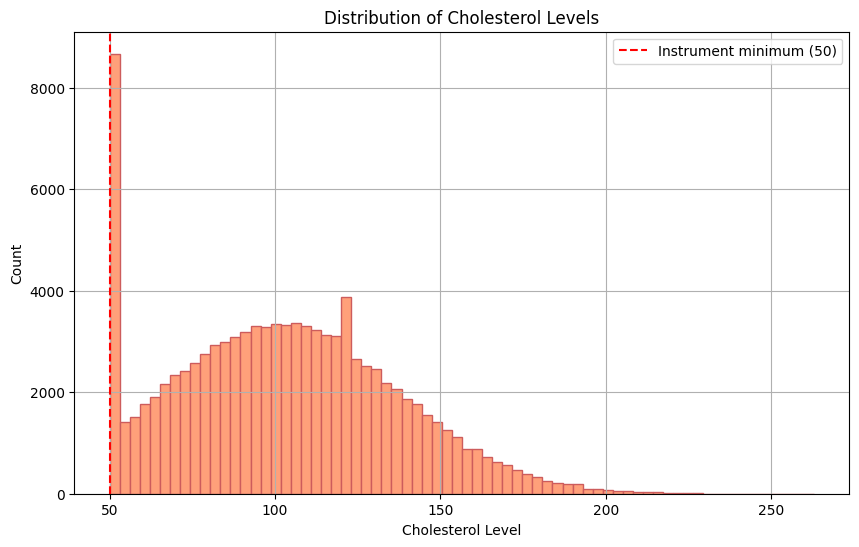

In [ ]:
# Cholesterol Level distrobution
plt.figure(figsize=(10, 6))
plt.hist(df['ldl_cholesterol'], bins=70, color='lightsalmon', edgecolor='indianred')
plt.xlabel('Cholesterol Level')
plt.ylabel('Count')
plt.title('Distribution of Cholesterol Levels')
plt.axvline(x=50, color='red', linestyle='--', label='Instrument minimum (50)')
plt.legend()
plt.grid()
plt.show()

As we can see, there is a very sharp spike at where cholesterol is 50, indicating that perhaps the instrument in which the cholesterol was measured did not go below 50, thus leading to any value below 50 being recorded as 50.

Additional Resources: [How to create a bar graph](https://matplotlib.org/stable/plot_types/basic/bar.html)

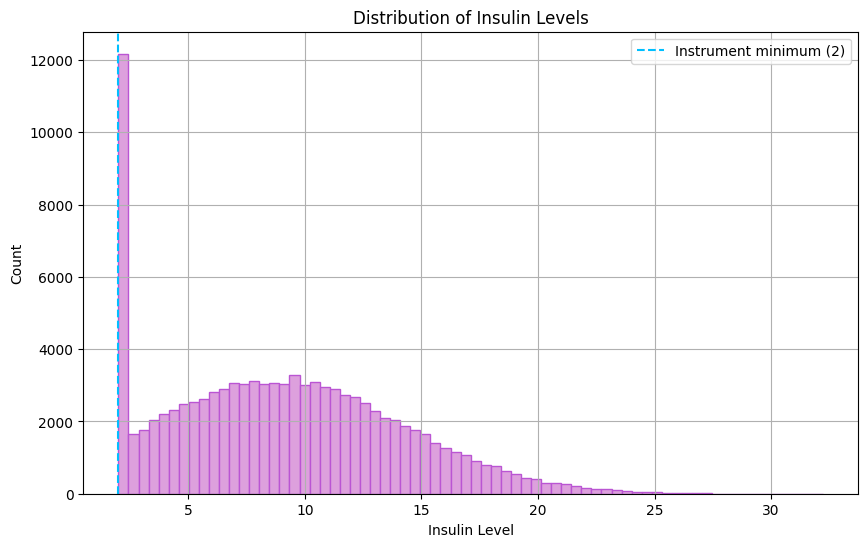

In [ ]:
# Insulin Level distrobution
plt.figure(figsize=(10, 6))
plt.hist(df['insulin_level'], bins=70, color='plum', edgecolor='mediumorchid')
plt.xlabel('Insulin Level')
plt.ylabel('Count')
plt.title('Distribution of Insulin Levels')
plt.axvline(x=2, color='deepskyblue', linestyle='--', label='Instrument minimum (2)')
plt.legend()
plt.grid()
plt.show()

Similarly, we see the same phenomenon happen with insulin level: there is a very sharp spike at insulin level = 2.

In both graphs, there is a large concentration of counts at the minimum values which may skew our results if not handeled properly. In this case, we opted to drop all the samples where Ldl Cholestrol is equal to 50 and where Insulin Level is equal to 2.

Comparison of cholesterol level counts: 


,count
ldl_cholesterol,
50,7430


,count
ldl_cholesterol,
51,358


,count
ldl_cholesterol,
52,435


,count
ldl_cholesterol,
53,448


,count
ldl_cholesterol,
54,464


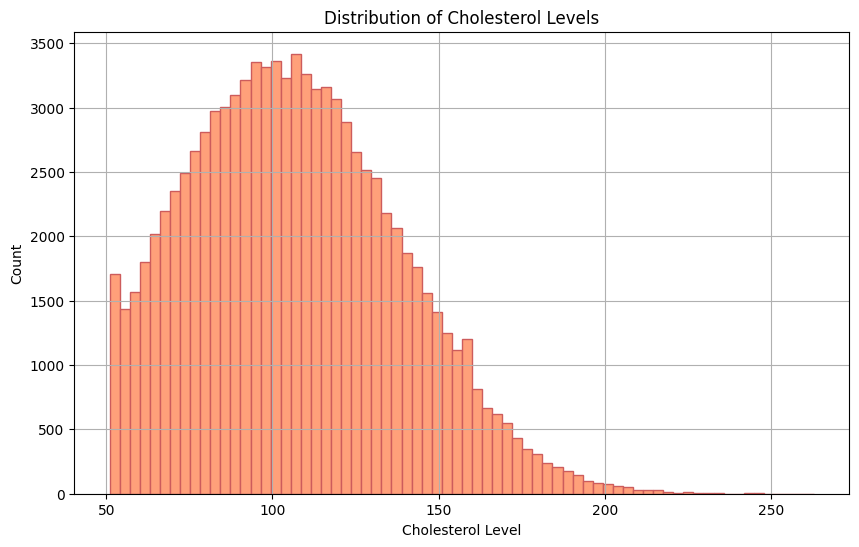

In [ ]:
# dropping all samples where Ldl Cholesterol is equal to 50

print("Comparison of cholesterol level counts: ")
display(df[df['ldl_cholesterol'] == 50]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 51]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 52]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 53]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 54]['ldl_cholesterol'].value_counts())

df = df[df['ldl_cholesterol'] > 50]
# will be empty
# display(df[df['ldl_cholesterol'] == 50]['ldl_cholesterol'].value_counts())
plt.figure(figsize=(10, 6))
plt.hist(df['ldl_cholesterol'], bins=70, color='lightsalmon', edgecolor='indianred')
plt.xlabel('Cholesterol Level')
plt.ylabel('Count')
plt.title('Distribution of Cholesterol Levels')
plt.grid()
plt.show()


To further prove our finidings, we also show the individual counts at where cholesterol level are 50, 51, 52, 53, and 54 before we drop all the points where cholesterol is 50. We clealy see that only when cholesterol is 50 there is a spike (7430 entries). When we drop the rows, the distribution looks a lot more normal.

Comparison of insulin level counts: 


,count
insulin_level,
2.0,9532


,count
insulin_level,
3.0,40


,count
insulin_level,
4.0,49


,count
insulin_level,
5.0,53


,count
insulin_level,
6.0,61


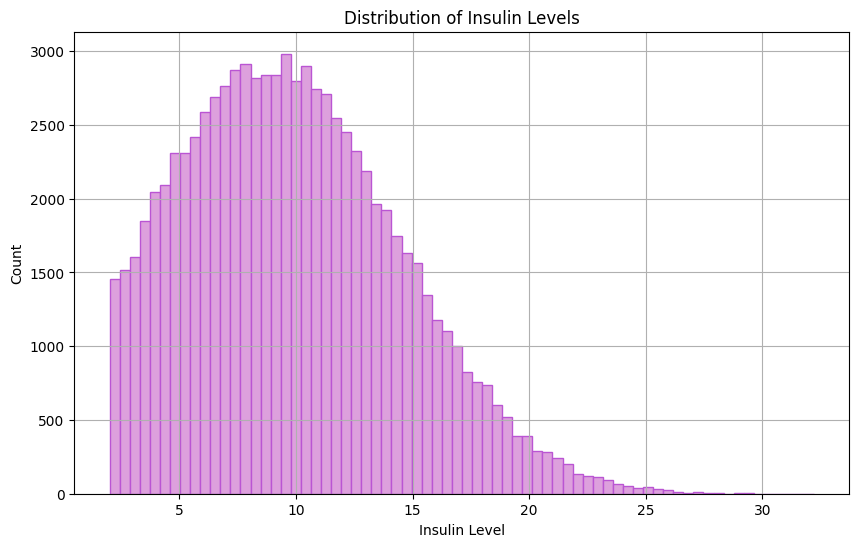

In [ ]:
# dropping all samples where Insulin Level is equal to 50

print("Comparison of insulin level counts: ")
display(df[df['insulin_level'] == 2]['insulin_level'].value_counts(),
df[df['insulin_level'] == 3]['insulin_level'].value_counts(),
df[df['insulin_level'] == 4]['insulin_level'].value_counts(),
df[df['insulin_level'] == 5]['insulin_level'].value_counts(),
df[df['insulin_level'] == 6]['insulin_level'].value_counts())

df = df[df['insulin_level'] > 2]
# will be empty
# display(df[df['insulin_level'] == 50]['insulin_level'].value_counts())

plt.figure(figsize=(10, 6))
plt.hist(df['insulin_level'], bins=70, color='plum', edgecolor='mediumorchid')
plt.xlabel('Insulin Level')
plt.ylabel('Count')
plt.title('Distribution of Insulin Levels')
plt.grid()
plt.show()

We do the same thing for insulin. We clealy see that only when insulin is 2 there is a spike (9532 entries). When we drop the rows, the distribution looks a lot more normal.

# **Organizing**

We are choosing which columns to use and cleaning these columns.

> Test 1, group by: "diabetes_stage", testing for ['ldl_cholesterol', 'insulin_level', 'hba1c', 'waist_to_hip_ratio']

> Test 2, testing categorical data columns: ['smoking_status', 'diabetes_stage']

> Test 3, group by: "diagnosed_diabetes", testing for "diet_score"


In [ ]:
diabetes_stage_detectors_df = list(df.groupby('diabetes_stage')[['ldl_cholesterol', 'insulin_level', 'hba1c', 'waist_to_hip_ratio']])

smoking_df = df[['smoking_status', 'diabetes_stage']]

df3s = list(df.groupby('diagnosed_diabetes')[['diet_score']])

# Test1

Doing consecutive ANOVA tests to see if any diabetes stages have an effect on the following values: ldl cholesterol, insulin levle, hba1c, and waist to hip ratio.

In [ ]:
# storing dataframes by diabetes stage
gestational = diabetes_stage_detectors_df[0][1]
no_diabetes = diabetes_stage_detectors_df[1][1]
pre_diabetes = diabetes_stage_detectors_df[2][1]
type1 = diabetes_stage_detectors_df[3][1]
type2 = diabetes_stage_detectors_df[4][1]


**Testing ldl cholesterol:**

H0 = Diabetes Stage has no effect on ldl cholesterol values

HA = Diabetes Stage has a significant effect on ldl cholesterol values


In [ ]:
ldl_gestational = gestational['ldl_cholesterol']
ldl_no_diabetes = no_diabetes['ldl_cholesterol']
ldl_pre_diabetes = pre_diabetes['ldl_cholesterol']
ldl_type1 = type1['ldl_cholesterol']
ldl_type2 = type2['ldl_cholesterol']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2)
print(f"The p-value we get from running an ANOVA test is: {res.pvalue.item()}")

# For the plots
colors = ['lightcoral', 'lightsalmon', 'gold', 'yellowgreen', 'mediumturquoise']
labels = ["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"]
ldls = [ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2]


The p-value we get from running an ANOVA test is: 3.2144539611955467e-81


Since our p-value is 3.21445396143435e-81, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Ldl Cholesterol values than the others.

In addition to displaying out p value, we will also create two graphs to better visualize the data we are working with: a box plot and a violin plot. Both plots are good ways to see the distribution of the data points:
- The box plot will show us what outliers there are and how many outliers there are.
- The violin plot will give us a better idea of the distribution of the data, specifically where data is concnetrated the most.

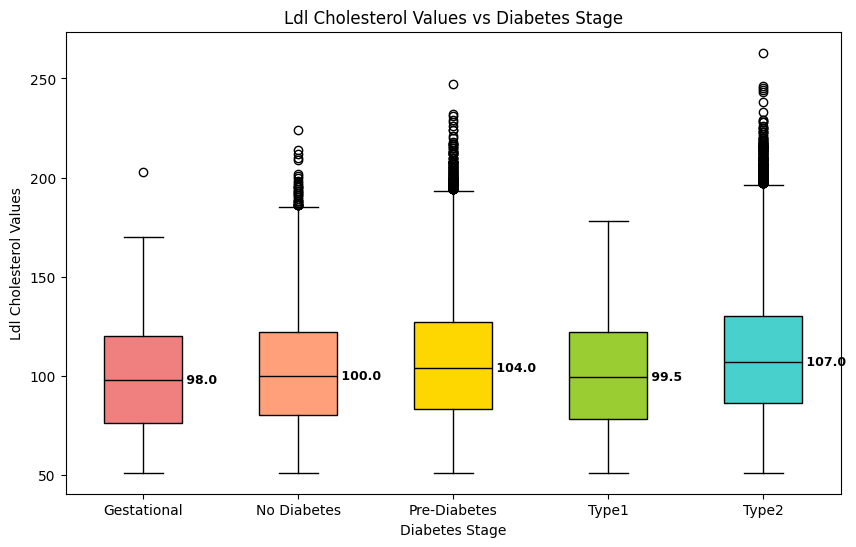

In [ ]:
# BOX PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Ldl Cholesterol Values vs Diabetes Stage")
ax.set_ylabel("Ldl Cholesterol Values")
ax.set_xlabel("Diabetes Stage")

bplot = ax.boxplot(ldls,
                   patch_artist=True,
                   tick_labels=labels,
                   medianprops=dict(color='black'))

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# label each median with its numeric value
medians = [np.median(data) for data in ldls]
for i, median in enumerate(medians):
    ax.text(i + 1.25, median, f' {median:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')
plt.show()

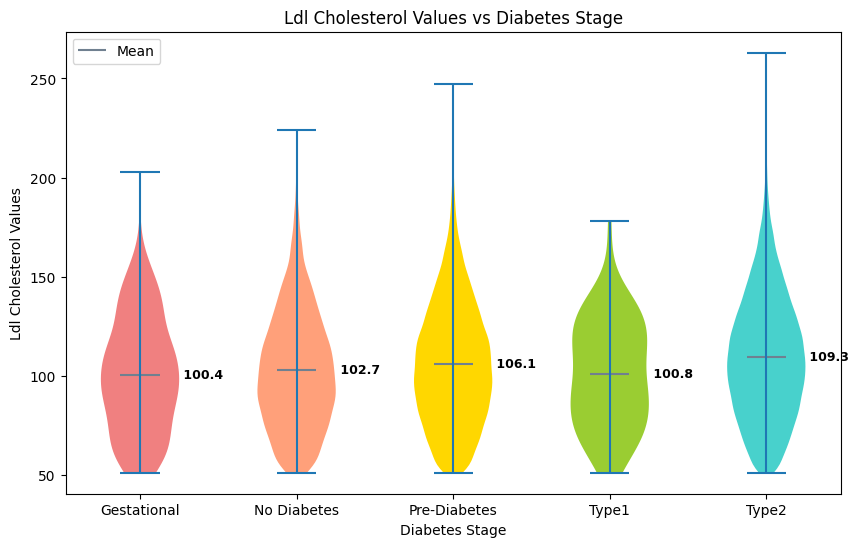

In [ ]:
# VIOLIN PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Ldl Cholesterol Values vs Diabetes Stage")
ax.set_ylabel("Ldl Cholesterol Values")
ax.set_xlabel("Diabetes Stage")

vplot = ax.violinplot(ldls, showmeans=True)

# set x-axis tick labels
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

# Fill with colors
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

# label each median with its numeric value
means = [np.mean(data) for data in ldls]
for i, mean in enumerate(means):
    ax.text(i + 1.25, mean, f' {mean:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

vplot['cmeans'].set_color('slategray')
vplot['cmeans'].set_label('Mean')
ax.legend()
plt.show()

Additional Resources: [How to make a box plot](https://matplotlib.org/stable/plot_types/stats/boxplot_plot.html)

Additional Resources: [How to make a violin plot](https://matplotlib.org/stable/plot_types/stats/violin.html)

From the plots above, we can see that the distribution of at least one of these categories do indeed differ. The graphs do look pretty alike but the distributions are not the same and there is crealy some difference between the means. For example, by looking at the violin plot we can see the means. Type 2 has a higher mean ldl cholesterol value than Gestational from what we can see which signifies that the distribution means are NOT the same. We must also keep in mind that the values are unfortunately cut off before a vlue of ldl cholesterol 50 which might play a role in how skewed the distributions are.  

We can also see some interesting patterns by abserving the different plots. With the boxplot, we note the excessive circles representing outliers. We propose that the cause of so many outliers is due to the large sample size. This occurs throughout all four categories we chose.

To demonstrate what we mean, we will look at the distribution of Cholesterol values for type 2 diabetes specifically. We can see that the distributions of cholesterol value are skewed by looking at the violin plots but for a closer look we will also look at a histogram:

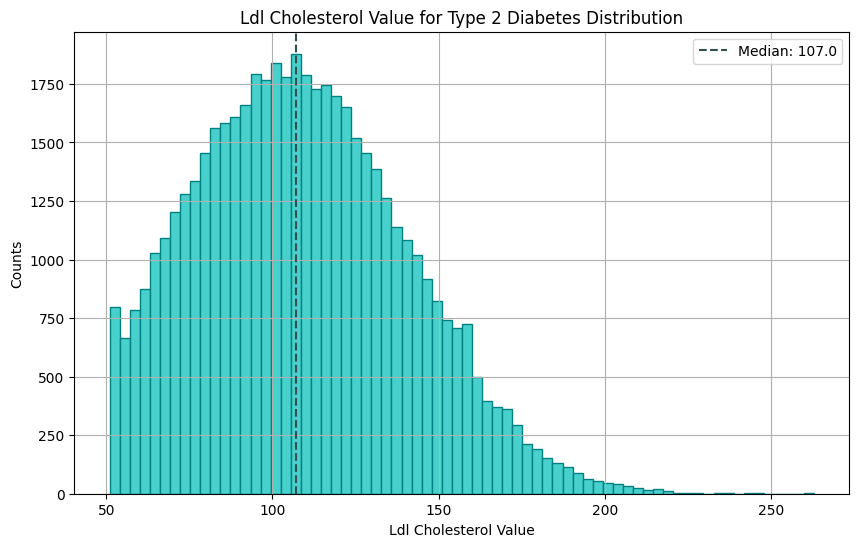

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(ldl_type2, bins=70, color='mediumturquoise', edgecolor='teal')
plt.title("Ldl Cholesterol Value for Type 2 Diabetes Distribution")
plt.xlabel("Ldl Cholesterol Value")
plt.ylabel("Counts")
plt.grid()

median = np.median(ldl_type2)
plt.axvline(median, color='darkslategray', linestyle='--', label=f'Median: {median:.1f}')
plt.legend()
plt.show()


Above, we can see that the data is skewed right. The counts taper off to zero as the ldl cholesterol values increase. When data is skewed, we see a lot of outliers to where the tail of the data goes. In the box plot above, we saw that Type 2 had a lot of outliers as ldl cholesterol values increased which is supported by the distribution of the data points (as visualized by the histogram above).

**Testing insulin level:**

H0 = Diabetes Stage has no effect on insulin level values

HA = Diabetes Stage has a significant effect on insulin level values

In [ ]:
insulin_gestational = gestational['insulin_level']
insulin_no_diabetes = no_diabetes['insulin_level']
insulin_pre_diabetes = pre_diabetes['insulin_level']
insulin_type1 = type1['insulin_level']
insulin_type2 = type2['insulin_level']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2)
print(f"The p-value we get by running an ANOVA test is: {res.pvalue.item()}")

The p-value we get by running an ANOVA test is: 6.25230684692778e-48


Since our p-value is 6.252306847369782e-48, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Insulin level values than the others.

We can also see this conclusion is supported by looking at a graph.

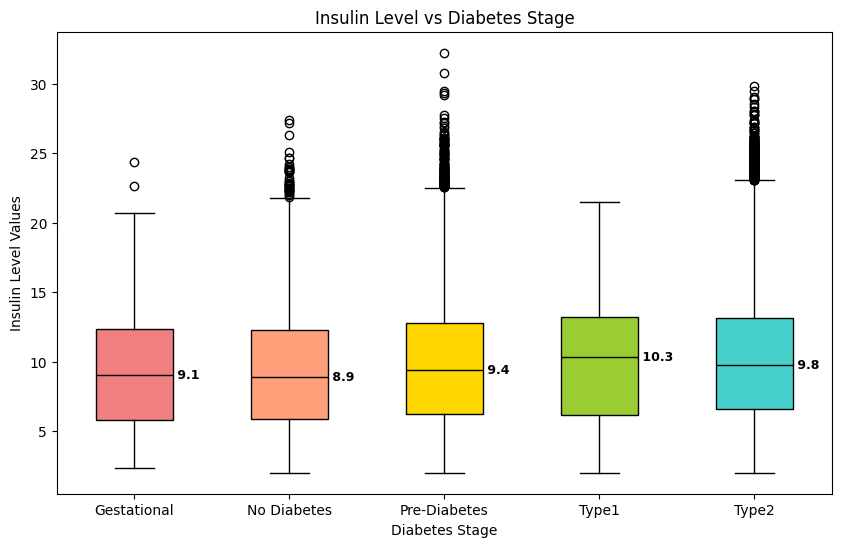

In [ ]:
insulin = [insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2]

# BOX PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Insulin Level vs Diabetes Stage")
ax.set_ylabel("Insulin Level Values")
ax.set_xlabel("Diabetes Stage")

bplot = ax.boxplot(insulin, patch_artist=True, tick_labels=labels,
                   medianprops=dict(color='black'))

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# label each median with its numeric value
medians = [np.median(data) for data in insulin]
for i, median in enumerate(medians):
    ax.text(i + 1.25, median, f' {median:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')
plt.show()

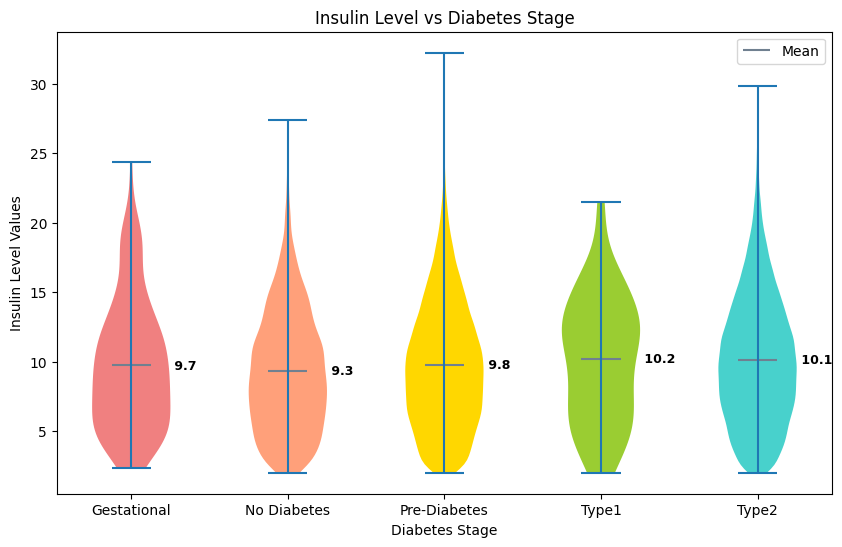

In [ ]:
# VIOLIN PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Insulin Level vs Diabetes Stage")
ax.set_ylabel("Insulin Level Values")
ax.set_xlabel("Diabetes Stage")

vplot = ax.violinplot(insulin, showmeans=True)

# set x-axis tick labels
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

# Fill with colors
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

# label each median with its numeric value
means = [np.mean(data) for data in insulin]
for i, mean in enumerate(means):
    ax.text(i + 1.25, mean, f' {mean:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

vplot['cmeans'].set_color('slategray')
vplot['cmeans'].set_label('Mean')
ax.legend()
plt.show()

Like before, we see that the distributions between the different diabetes types do differ in some way. For example, by looking at the violin plot we can see that Type 1 has a higher mean than no diabetes. This is also partially supported by the shapes of the distrubutions: Type 1 clearly has a peak higher in the distribution while no diabetes has a higher concentration of values where insulin levels are lower.

**Testing hba1c:**

H0 = Diabetes Stage has no effect on hba1c values

HA = Diabetes Stage has a significant effect on hba1c values

In [ ]:
hba1c_gestational = gestational['hba1c']
hba1c_no_diabetes = no_diabetes['hba1c']
hba1c_pre_diabetes = pre_diabetes['hba1c']
hba1c_type1 = type1['hba1c']
hba1c_type2 = type2['hba1c']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2)
print(f"The p-value we get by running an ANOVA test is: {res.pvalue.item()}")

The p-value we get by running an ANOVA test is: 0.0


Since our p-value is 0.0, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Hba1c values than the others.

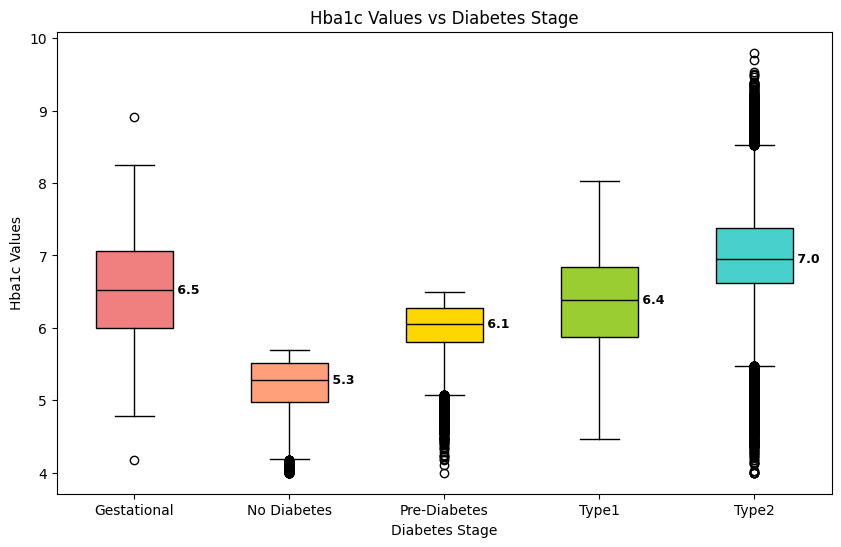

In [ ]:
hbac1 = [hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2]

# BOX PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Hba1c Values vs Diabetes Stage")
ax.set_ylabel("Hba1c Values")
ax.set_xlabel("Diabetes Stage")

bplot = ax.boxplot(hbac1,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   medianprops=dict(color='black'))

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# label each median with its numeric value
medians = [np.median(data) for data in hbac1]
for i, median in enumerate(medians):
    ax.text(i + 1.25, median, f' {median:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

plt.show()

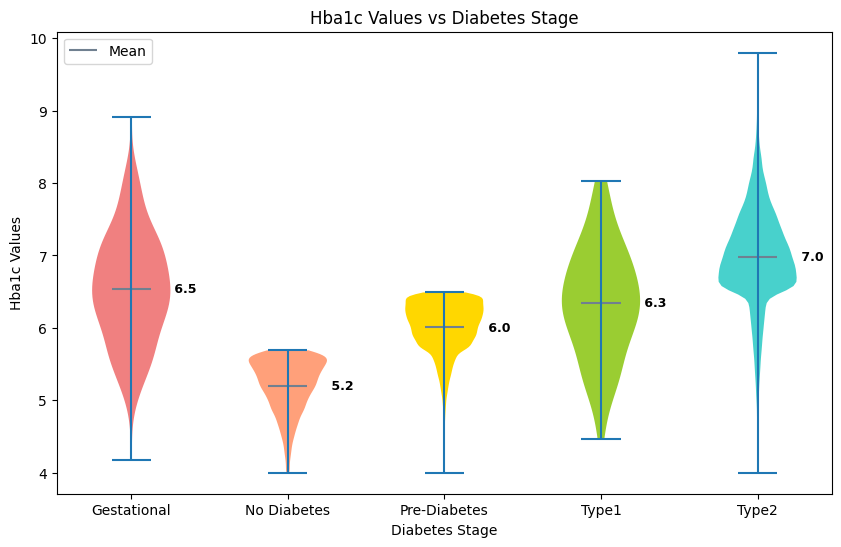

In [ ]:
# VIOLIN PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Hba1c Values vs Diabetes Stage")
ax.set_ylabel("Hba1c Values")
ax.set_xlabel("Diabetes Stage")

vplot = ax.violinplot(hbac1, showmeans=True)

# set x-axis tick labels
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

# Fill with colors
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

# label each median with its numeric value
means = [np.mean(data) for data in hbac1]
for i, mean in enumerate(means):
    ax.text(i + 1.25, mean, f' {mean:.1f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

vplot['cmeans'].set_color('slategray')
vplot['cmeans'].set_label('Mean')
ax.legend()
plt.show()

The distriutions of bhac1 values for the different types of diabetes visually look very different. We can clearly see that they all are different. No diabetes has a visibly lower mean than all the other distributions. We also see a clear concetration of people with type 2 diabetes have around 7 for their hbac1 levels. These differences support the p-value we got from the ANOVA test.

**Testing waist to hip ratio:**

H0 = Diabetes Stage has no effect on waist to hip ratio values

HA = Diabetes Stage has a significant effect on waist to hip ratio values

In [ ]:
whr_gestational = gestational['waist_to_hip_ratio']
whr_no_diabetes = no_diabetes['waist_to_hip_ratio']
whr_pre_diabetes = pre_diabetes['waist_to_hip_ratio']
whr_type1 = type1['waist_to_hip_ratio']
whr_type2 = type2['waist_to_hip_ratio']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2)
print(f"The p-value we get by running an ANOVA test is: {res.pvalue.item()}")

The p-value we get by running an ANOVA test is: 5.013627269745379e-116


Since our p-value is 5.013627270090914e-116, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Waist to Hip Ratio values than the others.

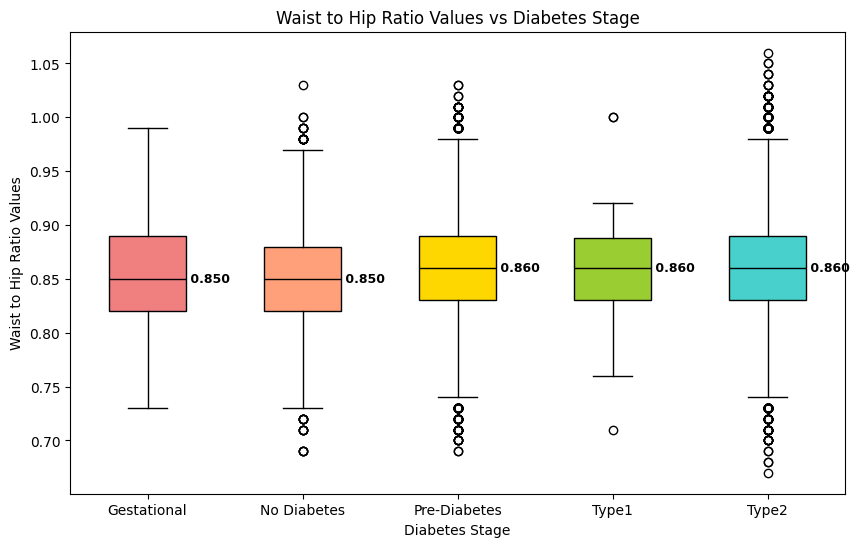

In [ ]:
whr = [whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2]

# BOX PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Waist to Hip Ratio Values vs Diabetes Stage")
ax.set_xlabel("Diabetes Stage")
ax.set_ylabel("Waist to Hip Ratio Values")

bplot = ax.boxplot(whr,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   medianprops=dict(color='black'))

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# label each median with its numeric value
medians = [np.median(data) for data in whr]
for i, median in enumerate(medians):
    ax.text(i + 1.25, median, f' {median:.3f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

plt.show()

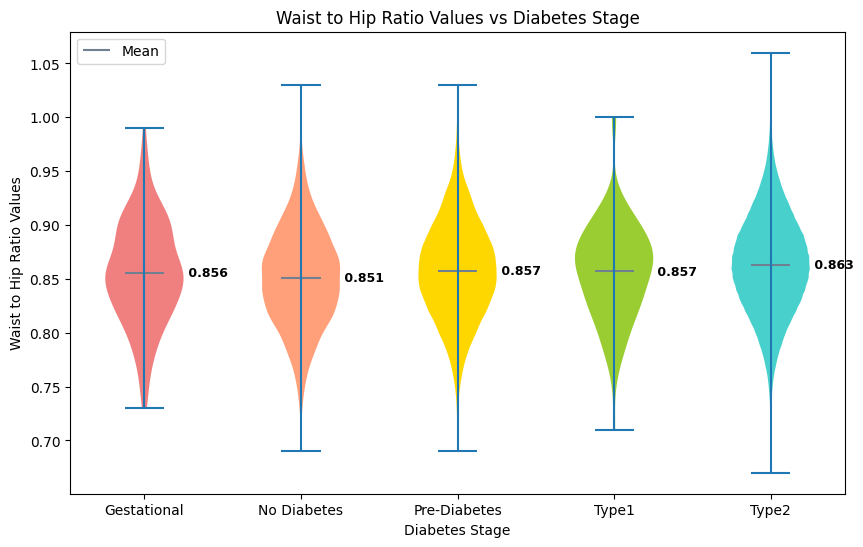

In [ ]:
# VIOLIN PLOT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Waist to Hip Ratio Values vs Diabetes Stage")
ax.set_xlabel("Diabetes Stage")
ax.set_ylabel("Waist to Hip Ratio Values")

vplot = ax.violinplot(whr, showmeans=True)

# set x-axis tick labels
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

# Fill with colors
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

# label each median with its numeric value
means = [np.mean(data) for data in whr]
for i, mean in enumerate(means):
    ax.text(i + 1.25, mean, f' {mean:.3f}',
            verticalalignment='center',
            fontsize=9,
            fontweight='bold')

vplot['cmeans'].set_color('slategray')
vplot['cmeans'].set_label('Mean')
ax.legend()
plt.show()

Teh distributions are visually very simialr and even their means are very simialr but because these values range from about 0.5-1.05, the decimal differences matter more than in the other distributions. We see that Type 2 diabetes seems to have a higher waist to hip ratio than the other distributions.

That being said, since all of these categories have significant p-values, we will perform a post hoc test on all categories.

In [ ]:
res = stats.tukey_hsd(ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2)
print("Ldl Cholesterol")
print(res)

res = stats.tukey_hsd(insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2)
print("Insulin")
print(res)

res = stats.tukey_hsd(hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2)
print("hba1c")
print(res)

res = stats.tukey_hsd(whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2)
print("Waist to Hip Ratio")
print(res)

Ldl Cholesterol
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.359     1.000   -10.565     9.847
 (0 - 2)     -3.346     0.894   -13.405     6.713
 (0 - 3)      1.322     1.000   -16.555    19.199
 (0 - 4)     -7.028     0.312   -17.065     3.009
 (1 - 0)      0.359     1.000    -9.847    10.565
 (1 - 2)     -2.987     0.002    -5.183    -0.791
 (1 - 3)      1.681     0.998   -13.259    16.622
 (1 - 4)     -6.669     0.000    -8.763    -4.575
 (2 - 0)      3.346     0.894    -6.713    13.405
 (2 - 1)      2.987     0.002     0.791     5.183
 (2 - 3)      4.668     0.912   -10.172    19.509
 (2 - 4)     -3.682     0.000    -4.863    -2.502
 (3 - 0)     -1.322     1.000   -19.199    16.555
 (3 - 1)     -1.681     0.998   -16.622    13.259
 (3 - 2)     -4.668     0.912   -19.509    10.172
 (3 - 4)     -8.351     0.539   -23.176     6.475
 (4 - 0)      7.028     0.312    -3.009    17.065
 (4 - 1)      6.669     0.00

# **Post Hoc Analysis**
## **Summary of *Significant* Group Comparisons:**
### **ldl Cholesterol**
- Gestational v pre-diabetes
- gestational v type 2
- no diabetes v pre-diabetes
- no diabetes v type 2
### **Insulin**
- no_diabetes v pre_diabetes
- no_diabetes v type 2
- pre_diabetes v type 2
### **hba1c**
all groups were significantly different EXCEPT
- gestational vs type 1
### **Waist to Hip Ratio**
- gestational v no_diabetes
- no_diabetes v pre_diabetes
- no_diabetes v type2

## **Conclusions:**
The medical measurements with the MOST significant group comparisons is **hba1c**, as all categories EXCEPT Gestational vs Type 1 have significant p values.
This means:
> The Diabetes Stage has a significant effect on hba1c (except between Gestational Diabetes and Type 1 Diabetes)

> So hba1c is not significantly different between Gestational and Type 1 diabetes, and should not be used when trying to decide between Gestational and Type 1

**Ldl Cholesterol** is a close second, but it is unable to detect significant differences between the categories and type 1 diabetes. With continued analysis of the box plot for ldl Cholesterol, type 1 diabetes overlaps with all the other diabetes stages. All the other boxes and whiskers have some distinction (larger range/Q3).

Waist to hip ratio has the "No Diabetes" label as an outlier (except with type 1, autoimmune diabetes), so it may be used as an initial test to see if ANY diabetes is detected.

Insulin has a significant difference between "No Diabetes", "Pre-diabetes", and "type 2". This means that insulin may be used for testing following the development of metabolic diabetes.

# **Test 2**

Performing a chi-squared between Smoking Status and Diabetes Stage to determine if these two categories are independent.

H0: Smoking status does not have an effect on diabetes stage.

HA: Smoking status has an effect on diabetes stage.

In [ ]:
type_1_ldl_cholesterol = type1['ldl_cholesterol']

df2 = df[['smoking_status', 'diabetes_stage']]

ctable = pd.crosstab(df['smoking_status'], df['diabetes_stage'])
s, pval, dof, expected = stats.chi2_contingency(ctable)
print(f"The p-value after conducting a chi-squared test is: {pval.item()}")

The p-value after conducting a chi-squared test is: 0.48348830839666357


Since our p-value is 0.8889454761878, which is greater than our α = 0.05, we fail to reject the null hypothesis and conclude that smoking status and diabetes stage are independent.

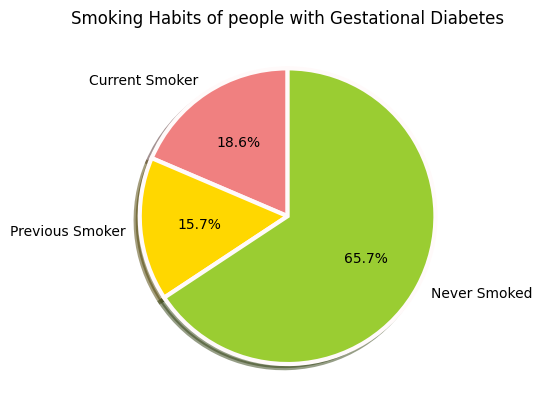

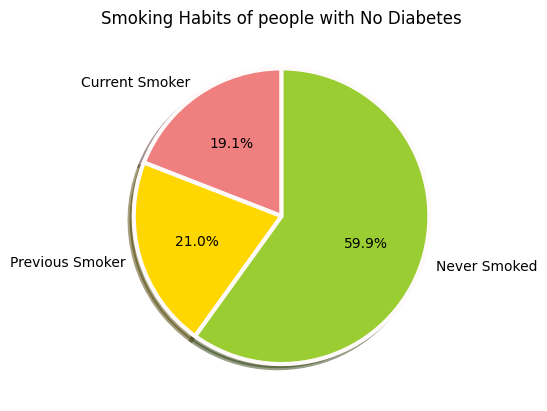

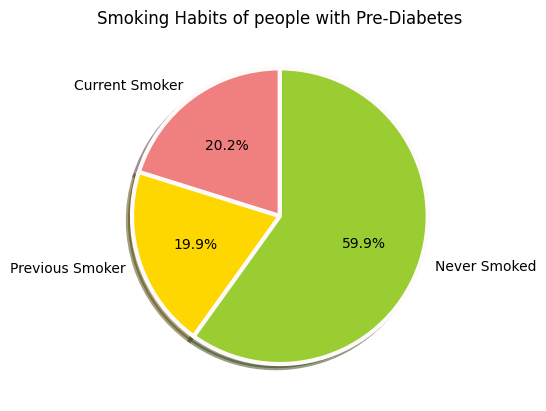

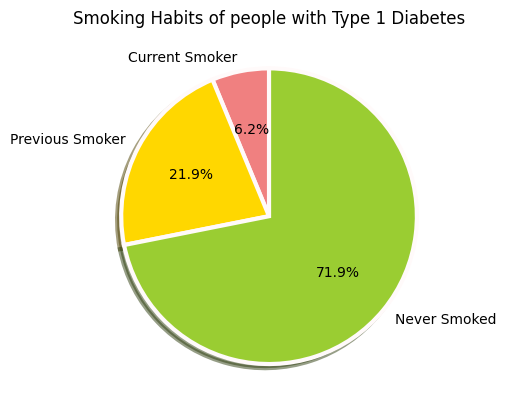

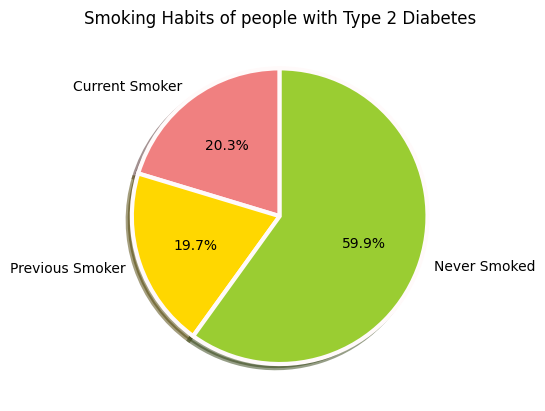

In [ ]:
# PIE CHARTS
labels = ['Current Smoker', 'Previous Smoker', 'Never Smoked']
plot1 = ctable['Gestational']
plot2 = ctable['No Diabetes']
plot3 = ctable['Pre-Diabetes']
plot4 = ctable['Type 1']
plot5 = ctable['Type 2']

plots = [plot1, plot2, plot3, plot4, plot5]

titles = ['Smoking Habits of people with Gestational Diabetes',
'Smoking Habits of people with No Diabetes',
'Smoking Habits of people with Pre-Diabetes',
'Smoking Habits of people with Type 1 Diabetes',
'Smoking Habits of people with Type 2 Diabetes']

i = 0
for plot in plots:
    fig, ax = plt.subplots()
    ax.pie(plot, labels=labels, autopct='%1.1f%%',
           colors=['lightcoral', 'gold', 'yellowgreen'], shadow = True,
        startangle = 90, wedgeprops= {"edgecolor":"snow",
            'linewidth': 3,
            'antialiased': True})
    ax.set_title(titles[i])
    i += 1
plt.show()


As we can see, the difference between the pie charts is actually not very noticible at all. This potentially supports that there isn't really a correlation between diabetes stage and smoking status. For a more unified visualization, here is also a stacked bar graph showing the different categories:

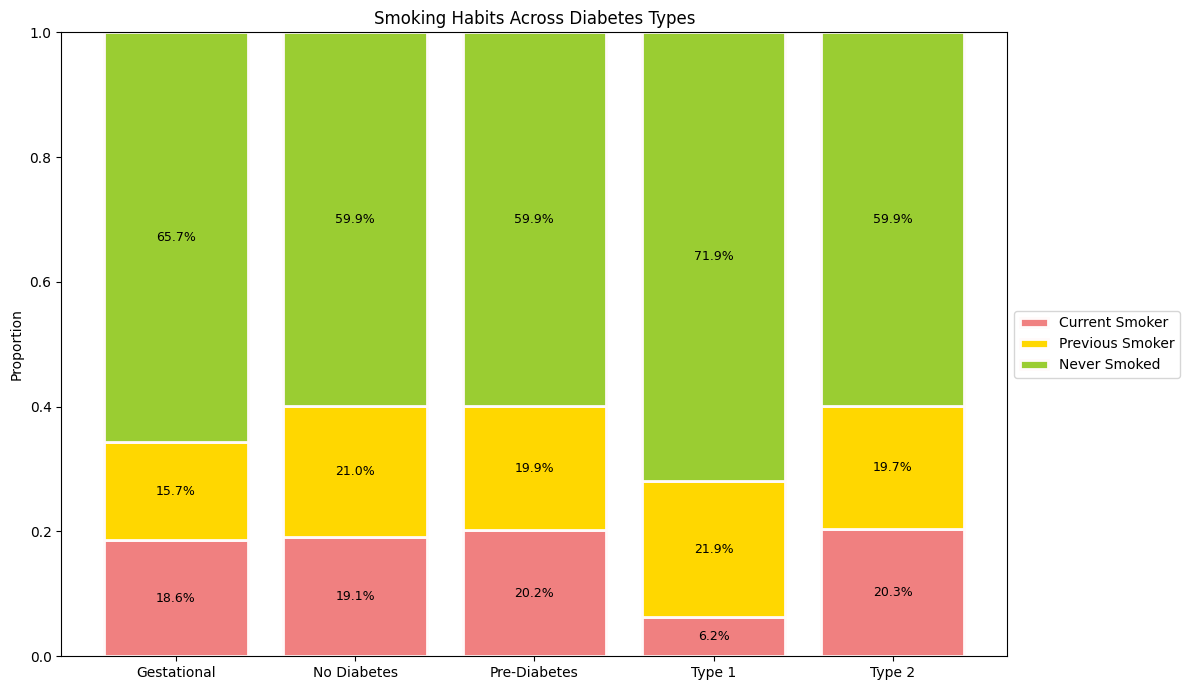

In [ ]:
labels = ['Current Smoker', 'Previous Smoker', 'Never Smoked']
colors = ['lightcoral', 'gold', 'yellowgreen']
diabetes_types = ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']

proportions = np.array([ctable[d].values / ctable[d].sum() for d in diabetes_types])

fig, ax = plt.subplots(figsize=(12, 7))

x_positions = np.arange(len(diabetes_types))
bar_width = 0.8

for j, smoking in enumerate(labels):
    heights = proportions[:, j]
    bottoms = proportions[:, :j].sum(axis=1)
    ax.bar(x_positions, heights, width=bar_width, bottom=bottoms,
           color=colors[j], edgecolor='snow', linewidth=2, label=smoking)
    for i, (h, b) in enumerate(zip(heights, bottoms)):
        if h > 0.05:
            ax.text(x_positions[i], b + h / 2, f'{h*100:.1f}%',
                    ha='center', va='center', fontsize=9)

ax.set_xticks(x_positions)
ax.set_xticklabels(diabetes_types)
ax.set_ylim(0, 1)
ax.set_ylabel('Proportion')
ax.set_title('Smoking Habits Across Diabetes Types')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Additional Resources: [How to make a pie chart](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html)

Additional Resources: [How to make a stacked bar graph](https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html)

# **Test 3**

Performing a one-tailed, two-sample T-test on Diagnosed Diabetes and Diet Score.

H0: The mean diet score of people with diabetes is not significantly different from people without diabetes.

HA: The mean diet score of people with diabetes is less than people without diabetes.

In [ ]:
df3s = list(df.groupby('diagnosed_diabetes')[['diet_score']])

yes_diabetes = df3s[0][1]
no_diabetes = df3s[1][1]

# 2-sample t-test
# mu1 < mu2
# H0 = The mean diet score of people with diabetes is not significantly different from
# people without diabetes
# HA = The mean diet score of people with diabetes is less than people without diabetes

# Calculate p-value
result = stats.ttest_ind(yes_diabetes['diet_score'], no_diabetes['diet_score'], alternative='less')

print(f"The p-value of conducting a 2-sample t-test is: {result.pvalue}")

The p-value of conducting a 2-sample t-test is: 0.999999999999065


Since our p-value is 1, which is greater than our α = 0.05, we fail to reject the null hypothesis and conclude that diabetes has no significant effect on someone’s mean diet score.

In order to visualize this, we create 2 histrograms that we overlay on top fo eachother to see that they almost overlap entirely. This means that the two distriutions are not very different and thus there is no significant difference as shown through the p-value.

Additional Resources: [How to make a histogram](https://matplotlib.org/stable/plot_types/stats/hist_plot.html)

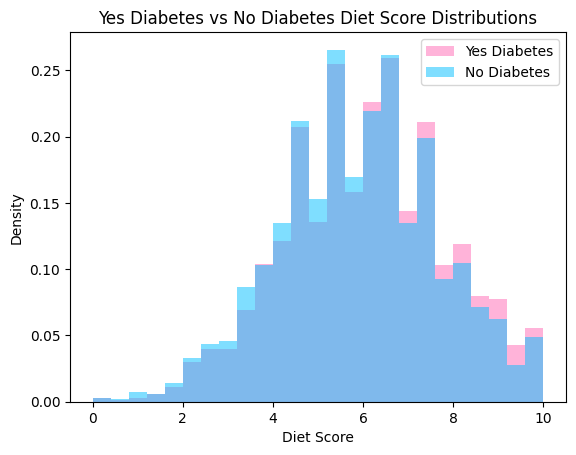

In [ ]:
# HISTOGRAMS
plt.hist(yes_diabetes, bins=25, density=True, alpha=0.5, label="Yes Diabetes", color='hotpink')
plt.hist(no_diabetes, bins=25, density=True, alpha=0.5, label="No Diabetes", color='deepskyblue')
plt.legend()
plt.title("Yes Diabetes vs No Diabetes Diet Score Distributions")
plt.xlabel("Diet Score")
plt.ylabel("Density")
plt.show()

# **EDA Reflection**

At the end of these three tests, only Test 1 had significant results. For Test 2, we found smoking had no significant
effect on diabetes type. For Test 3, we found diet had no significant score on having diabetes.

As such, for our ML model, we will be focusing on the exploration of Test 1. We will be
creating a classification model to classify patients diabetes stage based on the features:
ldl cholesterol, insulin levle, hba1c, and waist to hip ratio.